In [2]:
# 1. Bar plot for the three benchmarks/cohorts

import json
from pathlib import Path
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from configs.agent_config import AIDOC_HADM_IDS, CDM_HADM_IDS

# CDM / AIDOC distribution
cdm_counts = {k: len(v) for k, v in CDM_HADM_IDS.items()}
aidoc_counts = {k: len(v) for k, v in AIDOC_HADM_IDS.items()}

# VivaBench specialty distribution
vivabench_path = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/vivabench/benchmark_pubmed_test.jsonl")

vivabench_counter = Counter()

with vivabench_path.open("r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        row = json.loads(line)
        specialty = row.get("specialty_group", "Unknown")
        vivabench_counter[specialty] += 1


# Combine into long format
rows = []

for disease, count in cdm_counts.items():
    rows.append({
        "benchmark": "CDM",
        "group": disease,
        "count": count,
        "group_type": "disease",
    })

for disease, count in aidoc_counts.items():
    rows.append({
        "benchmark": "AIDOC",
        "group": disease,
        "count": count,
        "group_type": "disease",
    })

for specialty, count in vivabench_counter.items():
    rows.append({
        "benchmark": "VivaBench",
        "group": specialty,
        "count": count,
        "group_type": "specialty",
    })

df_dist = pd.DataFrame(rows)
df_dist




,benchmark,group,count,group_type
0,CDM,appendicitis,957,disease
1,CDM,cholecystitis,648,disease
2,CDM,diverticulitis,257,disease
3,CDM,pancreatitis,538,disease
4,AIDOC,appendicitis,148,disease
5,AIDOC,cholecystitis,129,disease
6,AIDOC,diverticulitis,54,disease
7,AIDOC,pancreatitis,52,disease
8,AIDOC,pneumonia,29,disease
9,AIDOC,pulmonary_embolism,90,disease


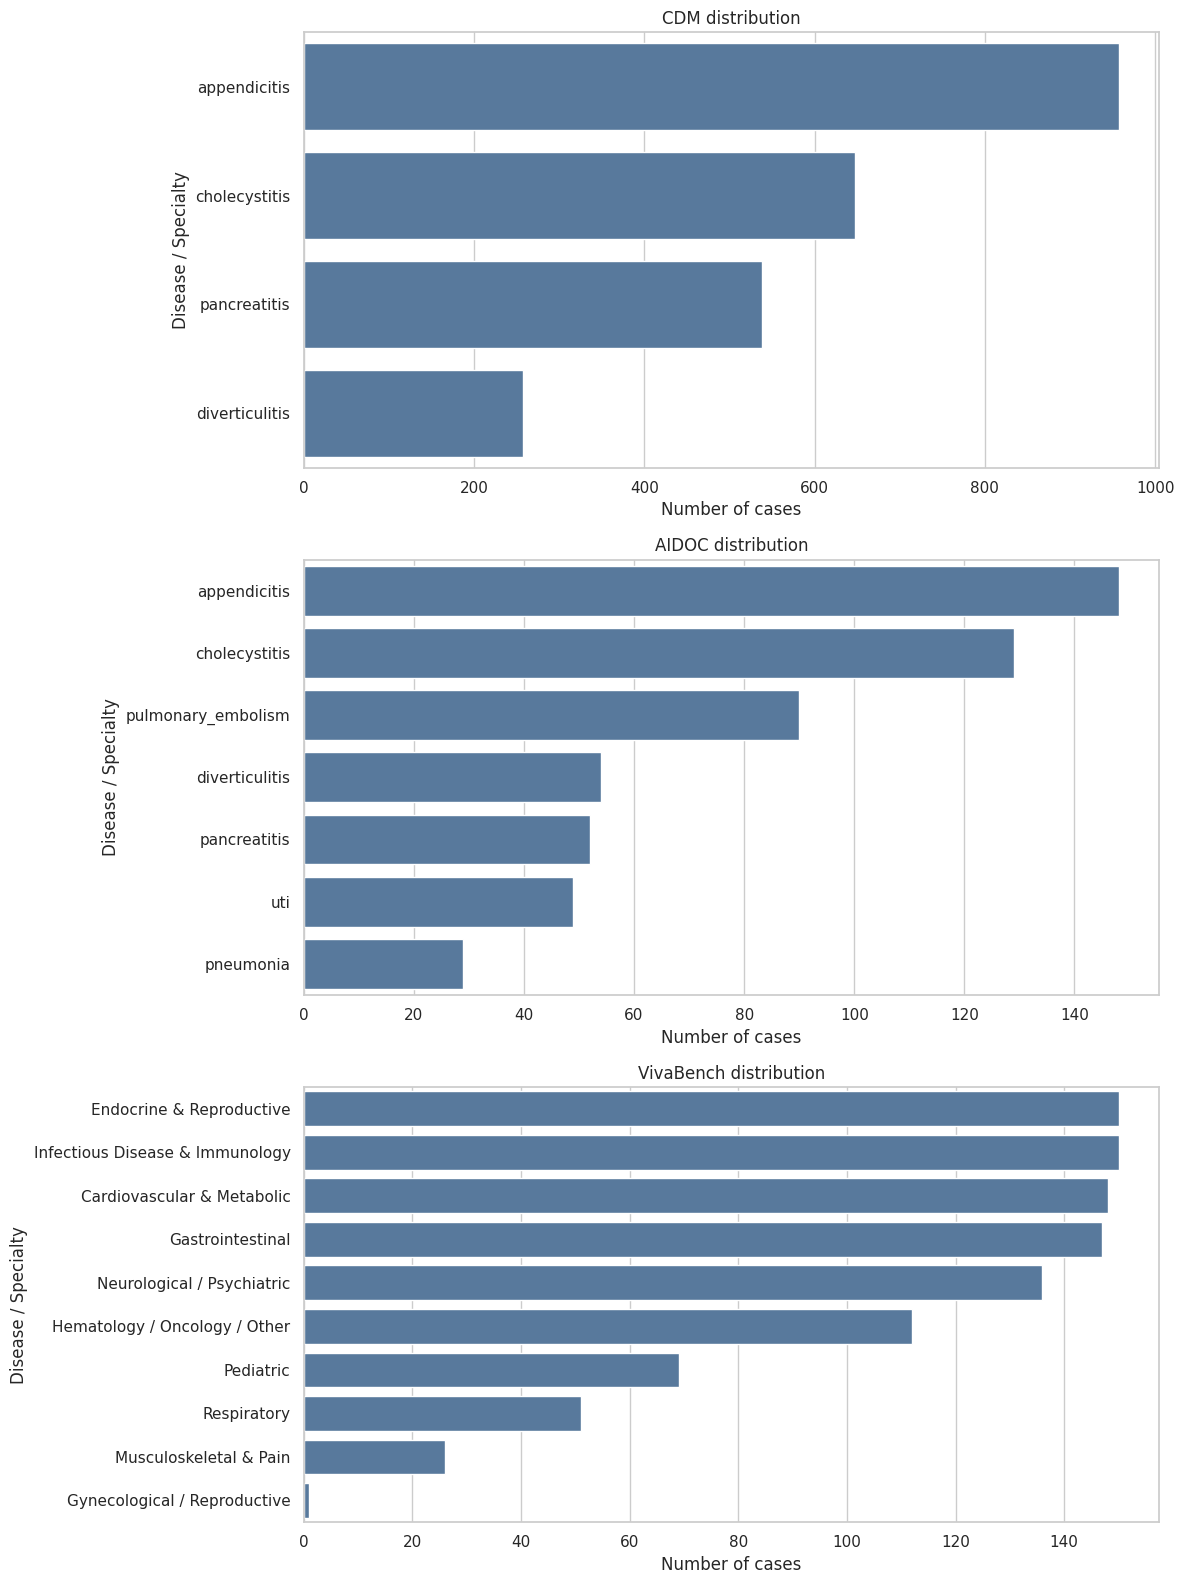

In [3]:
# Plot
sns.set(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(12, 16))

for ax, benchmark in zip(axes, ["CDM", "AIDOC", "VivaBench"]):
    sub = df_dist[df_dist["benchmark"] == benchmark].sort_values("count", ascending=False)
    sns.barplot(data=sub, x="count", y="group", ax=ax, color="#4C78A8")
    ax.set_title(f"{benchmark} distribution")
    ax.set_xlabel("Number of cases")
    ax.set_ylabel("Disease / Specialty")

plt.tight_layout()
plt.show()


In [4]:
# Read complete MIMIC-IV demographics
from pathlib import Path
import pandas as pd
import numpy as np

mimiciv_base = Path(
    "/mnt/bulk-vega/lizhang/LiWS/medical_bench/datasets/MIMIC-IV_v2.2/physionet.org/files/mimiciv/2.2"
)

patients_path = mimiciv_base / "hosp" / "patients.csv.gz"
admissions_path = mimiciv_base / "hosp" / "admissions.csv.gz"

patients = pd.read_csv(
    patients_path,
    usecols=["subject_id", "gender", "anchor_age"],
)

admissions = pd.read_csv(
    admissions_path,
    usecols=["subject_id", "hadm_id"],
)

patients["subject_id"] = patients["subject_id"].astype(int)
admissions["subject_id"] = admissions["subject_id"].astype(int)
admissions["hadm_id"] = admissions["hadm_id"].astype(int)

mimic_demo = admissions.merge(
    patients,
    on="subject_id",
    how="left",
)

mimic_demo.head()


,subject_id,hadm_id,gender,anchor_age
0,10000032,22595853,F,52
1,10000032,22841357,F,52
2,10000032,25742920,F,52
3,10000032,29079034,F,52
4,10000068,25022803,F,19


In [5]:
# Build the hadm_id -> gender / age mapping
hadm_to_demo = mimic_demo.set_index("hadm_id")[["gender", "anchor_age"]]


In [6]:
# 2. Cohort representation table
import numpy as np
from mimic_dataset_copy import MIMIC_Dataset

def load_mimic_dataset_for_benchmark(disease: str, benchmark: str) -> MIMIC_Dataset:
    benchmark = benchmark.upper()

    if benchmark == "CDM":
        return MIMIC_Dataset.load_from_pkl(disease)
    elif benchmark == "AIDOC":
        return MIMIC_Dataset.load_dataset(disease)
    else:
        raise ValueError(f"Unsupported benchmark: {benchmark}")


def safe_first(series):
    if series is None or len(series) == 0:
        return np.nan
    vals = pd.Series(series).dropna()
    if vals.empty:
        return np.nan
    return vals.iloc[0]

def extract_case_demographics(patient_data):
    age = np.nan
    sex = np.nan
    bmi = np.nan

    # sex
    if hasattr(patient_data, "patients") and patient_data.patients is not None and not patient_data.patients.empty:
        if "gender" in patient_data.patients.columns:
            sex = safe_first(patient_data.patients["gender"])

    # age: try direct age column first
    if hasattr(patient_data, "patients") and patient_data.patients is not None and not patient_data.patients.empty:
        if "anchor_age" in patient_data.patients.columns:
            age = safe_first(patient_data.patients["anchor_age"])
        elif "age" in patient_data.patients.columns:
            age = safe_first(patient_data.patients["age"])

    # bmi
    if hasattr(patient_data, "triage") and patient_data.triage is not None and not patient_data.triage.empty:
        for col in ["bmi", "BMI"]:
            if col in patient_data.triage.columns:
                bmi = safe_first(patient_data.triage[col])
                break

    return {
        "age": pd.to_numeric(age, errors="coerce"),
        "sex": str(sex).upper() if pd.notna(sex) else np.nan,
        "bmi": pd.to_numeric(bmi, errors="coerce"),
    }


In [7]:
# Generate a per-case demographics table for one benchmark
def build_demographics_df(hadm_dict, benchmark: str):
    rows = []

    for disease, hadm_ids in hadm_dict.items():
        ds = load_mimic_dataset_for_benchmark(disease, benchmark)

        for hadm_id in hadm_ids:
            if hadm_id not in ds.hadm_ids:
                continue

            patient_data = ds[hadm_id]
            demo = extract_case_demographics(patient_data)

            rows.append({
                "benchmark": benchmark,
                "dataset": disease,
                "hadm_id": hadm_id,
                "age": demo["age"],
                "sex": demo["sex"],
                "bmi": demo["bmi"],
            })

    return pd.DataFrame(rows)

df_aidoc_demo = build_demographics_df(AIDOC_HADM_IDS, benchmark="AIDOC")
df_cdm_demo = build_demographics_df(CDM_HADM_IDS, benchmark="CDM")
# Supplement CDM demographics.
df_cdm_demo = df_cdm_demo.copy()
df_cdm_demo["hadm_id"] = df_cdm_demo["hadm_id"].astype(int)

df_cdm_demo = df_cdm_demo.merge(
    mimic_demo[["hadm_id", "gender", "anchor_age"]],
    on="hadm_id",
    how="left",
)
df_cdm_demo["age"] = pd.to_numeric(df_cdm_demo["anchor_age"], errors="coerce")
df_cdm_demo["sex"] = df_cdm_demo["gender"].astype(str).str.upper()

df_cdm_demo = df_cdm_demo.drop(columns=["gender", "anchor_age"])

cohort_dir = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts")
cohort_dir.mkdir(parents=True, exist_ok=True)

df_cdm_demo.to_csv(cohort_dir / "cdm_case_demographics.csv", index=False)
df_aidoc_demo.to_csv(cohort_dir / "aidoc_case_demographics.csv", index=False)



# Summarize into a representation table
def summarize_cohort_table(df_demo, dataset_order):
    cols = ["All"] + dataset_order
    summary = {}

    for col in cols:
        if col == "All":
            sub = df_demo.copy()
        else:
            sub = df_demo[df_demo["dataset"] == col].copy()

        n = len(sub)

        age_mean = sub["age"].mean(skipna=True)
        age_sd = sub["age"].std(skipna=True)
        age_str = (
            f"{age_mean:.1f} ± {age_sd:.1f}"
            if pd.notna(age_mean) and pd.notna(age_sd)
            else "NA"
        )

        male_n = (sub["sex"] == "M").sum() + (sub["sex"] == "MALE").sum()
        female_n = (sub["sex"] == "F").sum() + (sub["sex"] == "FEMALE").sum()
        sex_str = f"{male_n} / {female_n}"

        bmi_mean = sub["bmi"].mean(skipna=True)
        bmi_sd = sub["bmi"].std(skipna=True)
        bmi_str = (
            f"{bmi_mean:.1f} ± {bmi_sd:.1f}"
            if pd.notna(bmi_mean) and pd.notna(bmi_sd)
            else "NA"
        )

        summary[col] = {
            "N in dataset": n,
            "Mean age (± SD)": age_str,
            "SEX male / female": sex_str,
            "BMI (± SD)": bmi_str,
        }

    return pd.DataFrame(summary)

cdm_table = summarize_cohort_table(df_cdm_demo, list(CDM_HADM_IDS.keys()))
aidoc_table = summarize_cohort_table(df_aidoc_demo, list(AIDOC_HADM_IDS.keys()))

0it [00:00, ?it/s]

15it [00:00, 45.47it/s]
15it [00:00, 68.88it/s]
15it [00:00, 112.18it/s]
15it [00:00, 117.37it/s]
15it [00:00, 129.48it/s]
15it [00:00, 115.01it/s]
15it [00:00, 122.13it/s]


In [8]:
print("cdm_table:\n", cdm_table)
print("aidoc_table:\n", aidoc_table)

cdm_table.to_csv(cohort_dir / "cdm_cohort_representation_table.csv")
print(cdm_table)

aidoc_table.to_csv(cohort_dir / "aidoc_cohort_representation_table.csv")
print(aidoc_table)

cdm_table:
                            All appendicitis cholecystitis diverticulitis  \
N in dataset              2400          957           648            257   
Mean age (± SD)    49.6 ± 19.4  38.9 ± 16.2   56.0 ± 18.6    58.5 ± 15.9   
SEX male / female  1124 / 1276    490 / 467     287 / 361      106 / 151   
BMI (± SD)                  NA           NA            NA             NA   

                  pancreatitis  
N in dataset               538  
Mean age (± SD)    56.8 ± 18.3  
SEX male / female    241 / 297  
BMI (± SD)                  NA  
aidoc_table:
                            All appendicitis cholecystitis diverticulitis  \
N in dataset               551          148           129             54   
Mean age (± SD)    48.4 ± 18.8  35.9 ± 14.0   48.6 ± 15.5    50.4 ± 15.1   
SEX male / female    257 / 294      84 / 64       51 / 78        27 / 27   
BMI (± SD)                  NA           NA            NA             NA   

                  pancreatitis    pneumonia pul

In [9]:
# Read and organize VivaBench demographics
import json
from pathlib import Path
import numpy as np
import pandas as pd

vivabench_path = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/vivabench/benchmark_pubmed_test.jsonl")

rows = []

with vivabench_path.open("r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        row = json.loads(line)
        clinicalcase = json.loads(row["clinicalcase"])

        demographics = clinicalcase.get("demographics", {}) or {}
        physical = clinicalcase.get("physical", {}) or {}
        vitals = physical.get("vitals", {}) or {}

        rows.append({
            "uid": row.get("uid"),
            "specialty_group": row.get("specialty_group", "Unknown"),
            "age": pd.to_numeric(demographics.get("age"), errors="coerce"),
            "gender": str(demographics.get("gender")).strip().upper() if demographics.get("gender") is not None else np.nan,
            "bmi": pd.to_numeric(vitals.get("bmi"), errors="coerce"),
        })

df_viva_demo = pd.DataFrame(rows)
df_viva_demo.head()


,uid,specialty_group,age,gender,bmi
0,pbm_36101544,Cardiovascular & Metabolic,40,FEMALE,NaN
1,pbm_33741059,Cardiovascular & Metabolic,38,FEMALE,NaN
2,pbm_36362504,Cardiovascular & Metabolic,38,MALE,30.99
3,pbm_20420664,Cardiovascular & Metabolic,33,FEMALE,NaN
4,pbm_32728521,Cardiovascular & Metabolic,41,MALE,NaN


In [10]:
# Generate the cohort representation table
def summarize_vivabench_cohort(df_demo: pd.DataFrame) -> pd.DataFrame:
    specialty_order = (
        df_demo["specialty_group"]
        .value_counts()
        .index
        .tolist()
    )

    cols = ["All"] + specialty_order
    summary = {}

    for col in cols:
        if col == "All":
            sub = df_demo.copy()
        else:
            sub = df_demo[df_demo["specialty_group"] == col].copy()

        n = len(sub)

        age_mean = sub["age"].mean(skipna=True)
        age_sd = sub["age"].std(skipna=True)
        age_non_null = sub["age"].dropna()
        if len(age_non_null) == 0:
            age_str = "NA"
        elif len(age_non_null) == 1:
            age_str = f"{age_non_null.iloc[0]:.1f} (n=1)"
        else:
            age_str = f"{age_non_null.mean():.1f} ± {age_non_null.std():.1f}"


        male_n = sub["gender"].isin(["M", "MALE"]).sum()
        female_n = sub["gender"].isin(["F", "FEMALE"]).sum()
        sex_str = f"{male_n} / {female_n}"

        bmi_non_null = sub["bmi"].dropna()
        if len(bmi_non_null) > 0:
            bmi_mean = bmi_non_null.mean()
            bmi_sd = bmi_non_null.std()
            bmi_str = f"{bmi_mean:.1f} ± {bmi_sd:.1f} (n={len(bmi_non_null)})"
        else:
            bmi_str = "NA"

        summary[col] = {
            "N in dataset": n,
            "Mean age (± SD)": age_str,
            "SEX male / female": sex_str,
            "BMI (± SD)": bmi_str,
        }

    return pd.DataFrame(summary)

vivabench_table = summarize_vivabench_cohort(df_viva_demo)
vivabench_table


,All,Endocrine & Reproductive,Infectious Disease & Immunology,Cardiovascular & Metabolic,Gastrointestinal,Neurological / Psychiatric,Hematology / Oncology / Other,Pediatric,Respiratory,Musculoskeletal & Pain,Gynecological / Reproductive
N in dataset,990,150,150,148,147,136,112,69,51,26,1
Mean age (± SD),45.8 ± 19.9,44.0 ± 18.4,47.4 ± 18.6,50.3 ± 18.0,50.7 ± 16.6,51.2 ± 16.7,49.1 ± 17.6,9.7 ± 5.1,46.1 ± 19.1,48.7 ± 18.4,24.0 (n=1)
SEX male / female,523 / 466,56 / 93,99 / 51,78 / 70,92 / 55,69 / 67,48 / 64,35 / 34,27 / 24,19 / 7,0 / 1
BMI (± SD),24.1 ± 8.0 (n=70),23.2 ± 6.2 (n=30),29.1 ± 5.9 (n=5),30.5 ± 10.1 (n=6),19.7 ± 5.3 (n=9),26.8 ± 5.1 (n=4),31.3 ± 13.5 (n=4),12.8 ± 8.3 (n=4),25.5 ± 6.8 (n=7),23.2 ± nan (n=1),NA


In [39]:
df_viva_demo["specialty_group"].value_counts()
df_viva_demo.to_csv(cohort_dir / "vivabench_case_demographics.csv", index=False)

# out_path = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts/vivabench_cohort_representation_table.csv"
vivabench_table.to_csv(cohort_dir / "vivabench_cohort_representation_table.csv")
# print(out_path)

In [44]:
'''
建议做两类图，分别回答不同问题：

1. Gender composition

用 stacked bar chart
每个 benchmark 一根柱子
显示 Male / Female 的比例或数量
'''

from pathlib import Path
import pandas as pd

cohort_dir = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts")

df_cdm_demo = pd.read_csv(cohort_dir / "cdm_case_demographics.csv")
df_aidoc_demo = pd.read_csv(cohort_dir / "aidoc_case_demographics.csv")
df_viva_demo = pd.read_csv(cohort_dir / "vivabench_case_demographics.csv")


df_cdm_plot = df_cdm_demo[["benchmark", "age", "sex"]].copy()
df_aidoc_plot = df_aidoc_demo[["benchmark", "age", "sex"]].copy()

df_viva_plot = df_viva_demo.rename(columns={"gender": "sex"})[["age", "sex"]].copy()
df_viva_plot["benchmark"] = "VivaBench"

df_demo_all = pd.concat(
    [df_cdm_plot, df_aidoc_plot, df_viva_plot],
    ignore_index=True,
)

df_demo_all["benchmark"] = pd.Categorical(
    df_demo_all["benchmark"],
    categories=["CDM", "AIDOC", "VivaBench"],
    ordered=True,
)

df_demo_all["sex"] = (
    df_demo_all["sex"]
    .astype(str)
    .str.upper()
    .replace({
        "M": "Male",
        "MALE": "Male",
        "F": "Female",
        "FEMALE": "Female",
        "NAN": pd.NA,
        "UNKNOWN": pd.NA,
    })
)


/tmp/ipykernel_830762/2771520736.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["benchmark", "sex"])
/tmp/ipykernel_830762/2771520736.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  / gender_counts.groupby("benchmark")["count"].transform("sum")


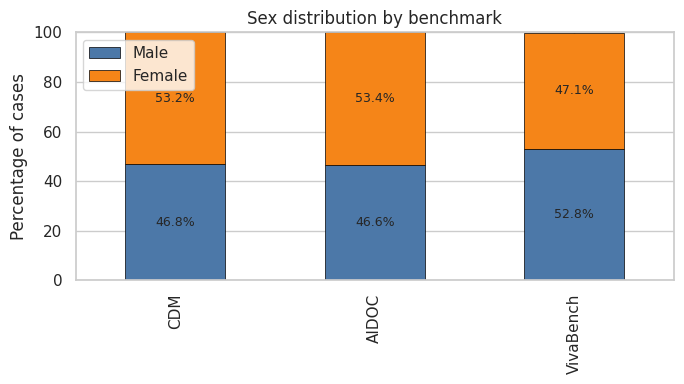

In [49]:
# Gender 100% stacked bar
gender_counts = (
    df_demo_all
    .dropna(subset=["sex"])
    .groupby(["benchmark", "sex"])
    .size()
    .reset_index(name="count")
)

gender_counts["percent"] = (
    gender_counts["count"]
    / gender_counts.groupby("benchmark")["count"].transform("sum")
    * 100
)

gender_pivot = gender_counts.pivot(
    index="benchmark",
    columns="sex",
    values="percent",
).fillna(0)

gender_pivot = gender_pivot[["Male", "Female"]]

ax = gender_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 4),
    color=["#4C78A8", "#F58518"],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_ylabel("Percentage of cases")
ax.set_xlabel("")
ax.set_title("Sex distribution by benchmark")
ax.legend(title="")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=9)

plt.tight_layout()
out_dir = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts")
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "sex_distribution_by_benchmark.png", dpi=600, bbox_inches="tight")
plt.show()


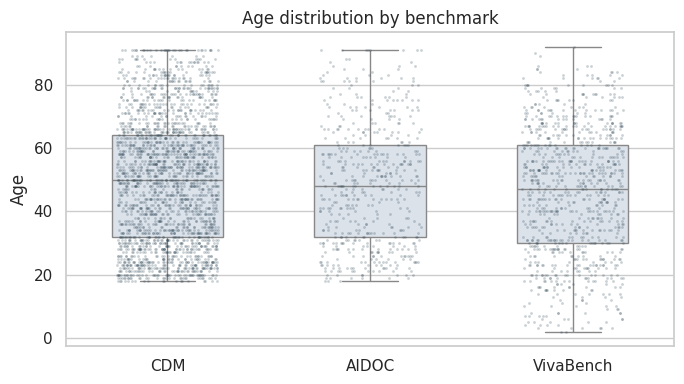

In [50]:
# Age distribution boxplot
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_demo_all,
    x="benchmark",
    y="age",
    color="#D9E2EC",
    width=0.55,
    showfliers=False,
)

sns.stripplot(
    data=df_demo_all,
    x="benchmark",
    y="age",
    color="#2F4858",
    alpha=0.25,
    size=2,
    jitter=0.25,
)

plt.xlabel("")
plt.ylabel("Age")
plt.title("Age distribution by benchmark")
plt.tight_layout()

# To save the most recently generated figures, add the following before each plt.show():
plt.savefig(out_dir / "age_distribution_by_benchmark.png", dpi=600, bbox_inches="tight")

plt.show()


In [51]:
'''
CDM: age by disease
AIDOC: age by disease
VivaBench: age by specialty group
'''
def plot_age_by_group(
    df: pd.DataFrame,
    group_col: str,
    title: str,
    output_path: Path | None = None,
    figsize=(10, 6),
):
    plot_df = df.copy()
    plot_df["age"] = pd.to_numeric(plot_df["age"], errors="coerce")
    plot_df = plot_df.dropna(subset=["age", group_col])

    order = (
        plot_df.groupby(group_col)["age"]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    plt.figure(figsize=figsize)

    sns.boxplot(
        data=plot_df,
        x="age",
        y=group_col,
        order=order,
        color="#D9E2EC",
        width=0.55,
        showfliers=False,
    )

    sns.stripplot(
        data=plot_df,
        x="age",
        y=group_col,
        order=order,
        color="#2F4858",
        alpha=0.25,
        size=2,
        jitter=0.25,
    )

    plt.title(title)
    plt.xlabel("Age")
    plt.ylabel("")
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()


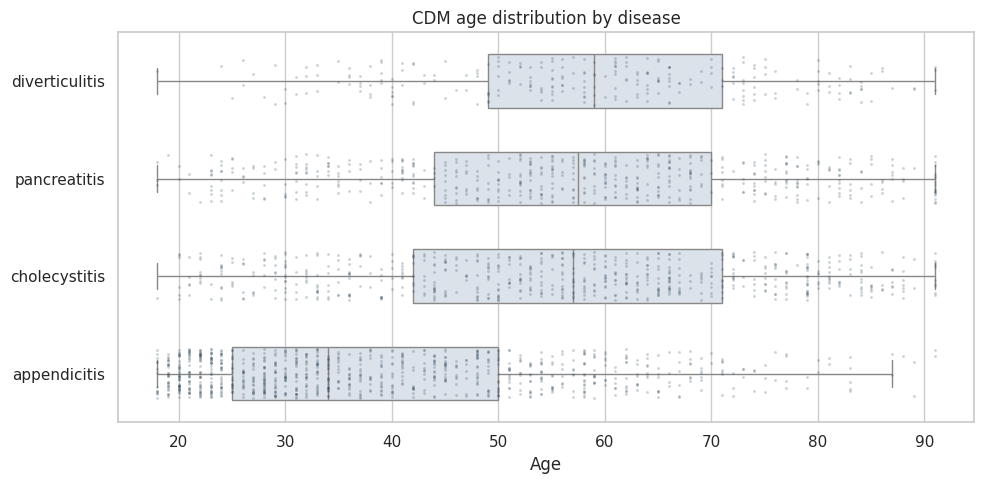

In [52]:
# CDM: age by disease
plot_age_by_group(
    df=df_cdm_demo,
    group_col="dataset",
    title="CDM age distribution by disease",
    output_path=cohort_dir / "cdm_age_by_disease.png",
    figsize=(10, 5),
)


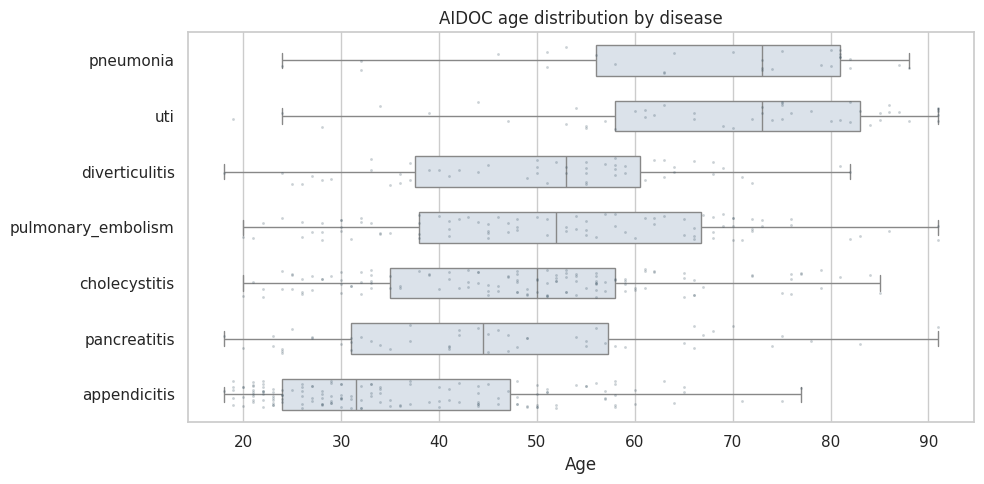

In [53]:
# AIDOC: age by disease
plot_age_by_group(
    df=df_aidoc_demo,
    group_col="dataset",
    title="AIDOC age distribution by disease",
    output_path=cohort_dir / "aidoc_age_by_disease.png",
    figsize=(10, 5),
)


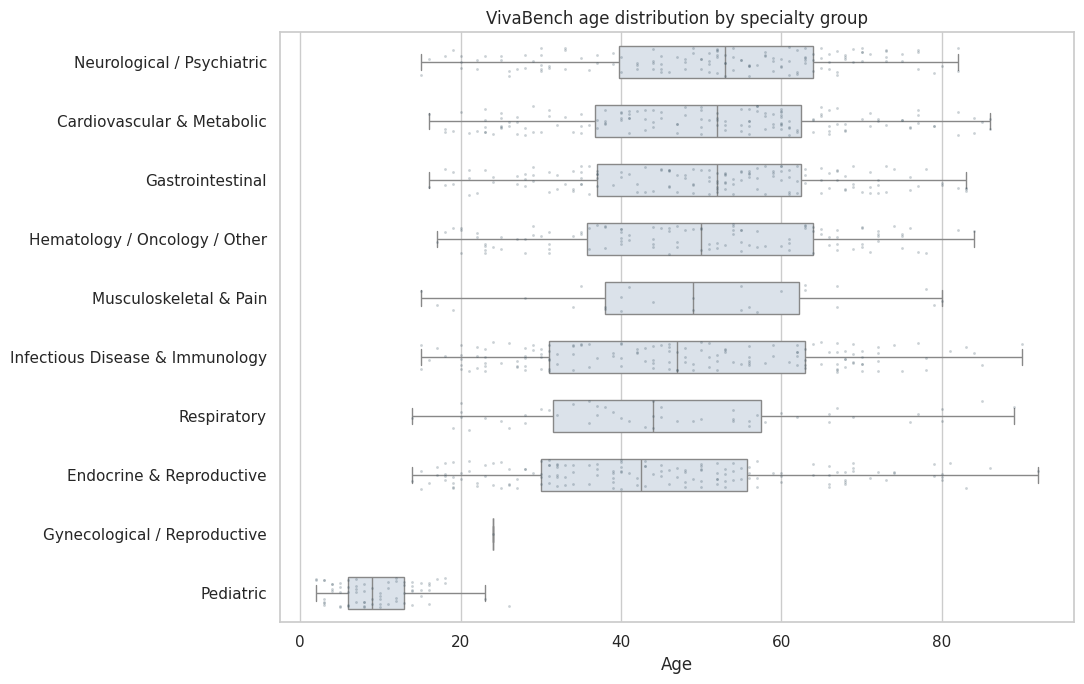

In [54]:
#VivaBench: age by specialty group
plot_age_by_group(
    df=df_viva_demo,
    group_col="specialty_group",
    title="VivaBench age distribution by specialty group",
    output_path=cohort_dir / "vivabench_age_by_specialty.png",
    figsize=(11, 7),
)


In [55]:
'''
CDM: sex by disease
AIDOC: sex by disease
VivaBench: sex by specialty group
'''

def normalize_sex(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.upper()
        .replace({
            "M": "Male",
            "MALE": "Male",
            "F": "Female",
            "FEMALE": "Female",
            "NAN": pd.NA,
            "NONE": pd.NA,
            "UNKNOWN": pd.NA,
        })
    )

def plot_sex_by_group(
    df: pd.DataFrame,
    group_col: str,
    sex_col: str,
    title: str,
    output_path: Path | None = None,
    figsize=(10, 5),
    normalize_to_percent=True,
):
    plot_df = df.copy()
    plot_df["sex_clean"] = normalize_sex(plot_df[sex_col])
    plot_df = plot_df.dropna(subset=[group_col, "sex_clean"])

    counts = (
        plot_df
        .groupby([group_col, "sex_clean"])
        .size()
        .reset_index(name="count")
    )

    count_pivot = counts.pivot(
        index=group_col,
        columns="sex_clean",
        values="count",
    ).fillna(0)

    for col in ["Male", "Female"]:
        if col not in count_pivot.columns:
            count_pivot[col] = 0

    count_pivot = count_pivot[["Male", "Female"]]

    # Sort by total sample size, descending
    count_pivot = count_pivot.loc[count_pivot.sum(axis=1).sort_values(ascending=False).index]

    if normalize_to_percent:
        plot_data = count_pivot.div(count_pivot.sum(axis=1), axis=0) * 100
        ylabel = "Percentage of cases"
        ylim = (0, 100)
        label_fmt = "%.1f%%"
    else:
        plot_data = count_pivot
        ylabel = "Number of cases"
        ylim = None
        label_fmt = "%.0f"

    ax = plot_data.plot(
        kind="barh",
        stacked=True,
        figsize=figsize,
        color=["#4C78A8", "#F58518"],
        edgecolor="black",
        linewidth=0.5,
    )

    ax.set_title(title)
    ax.set_xlabel(ylabel)
    ax.set_ylabel("")
    if ylim is not None:
        ax.set_xlim(*ylim)

    ax.legend(title="", loc="lower right")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt=label_fmt,
            label_type="center",
            fontsize=8,
            color="white",
        )

    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()




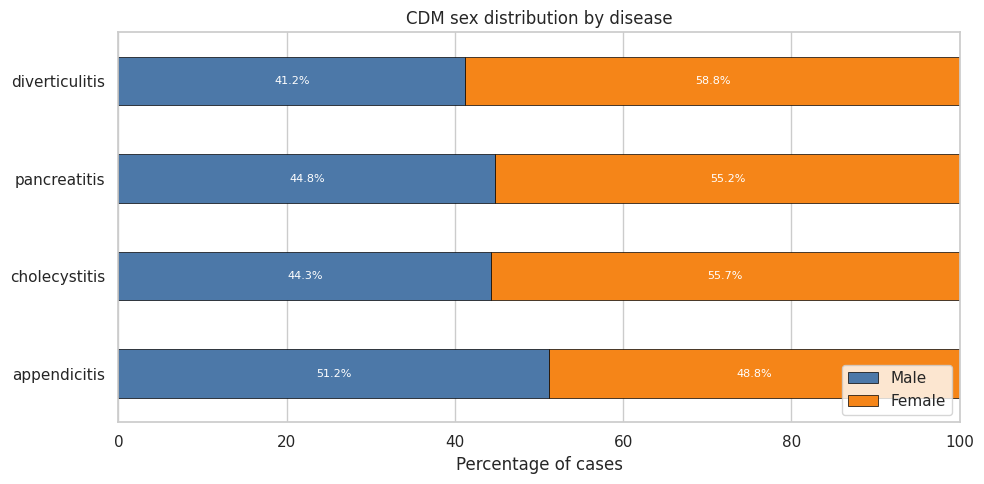

In [56]:
# CDM: sex by disease
plot_sex_by_group(
    df=df_cdm_demo,
    group_col="dataset",
    sex_col="sex",
    title="CDM sex distribution by disease",
    output_path=cohort_dir / "cdm_sex_by_disease.png",
    figsize=(10, 5),
)


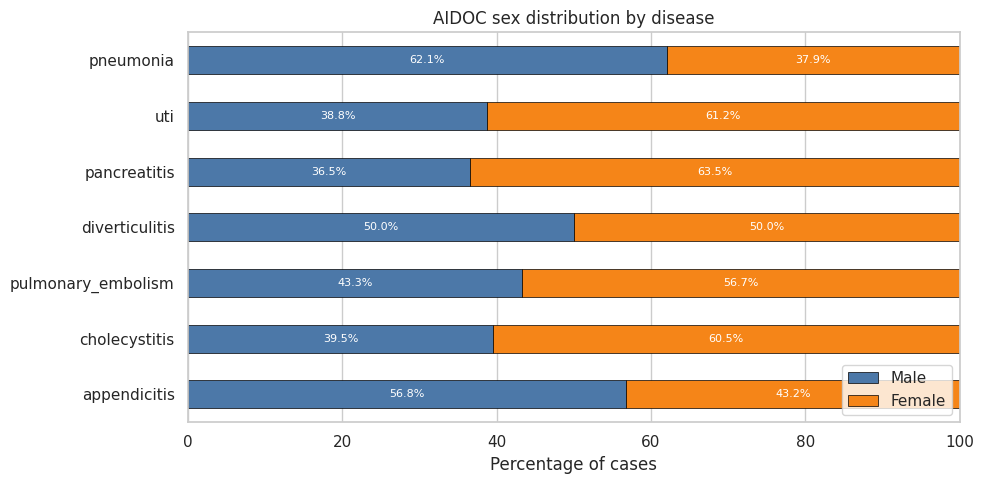

In [57]:
# AIDOC: sex by disease
plot_sex_by_group(
    df=df_aidoc_demo,
    group_col="dataset",
    sex_col="sex",
    title="AIDOC sex distribution by disease",
    output_path=cohort_dir / "aidoc_sex_by_disease.png",
    figsize=(10, 5),
)


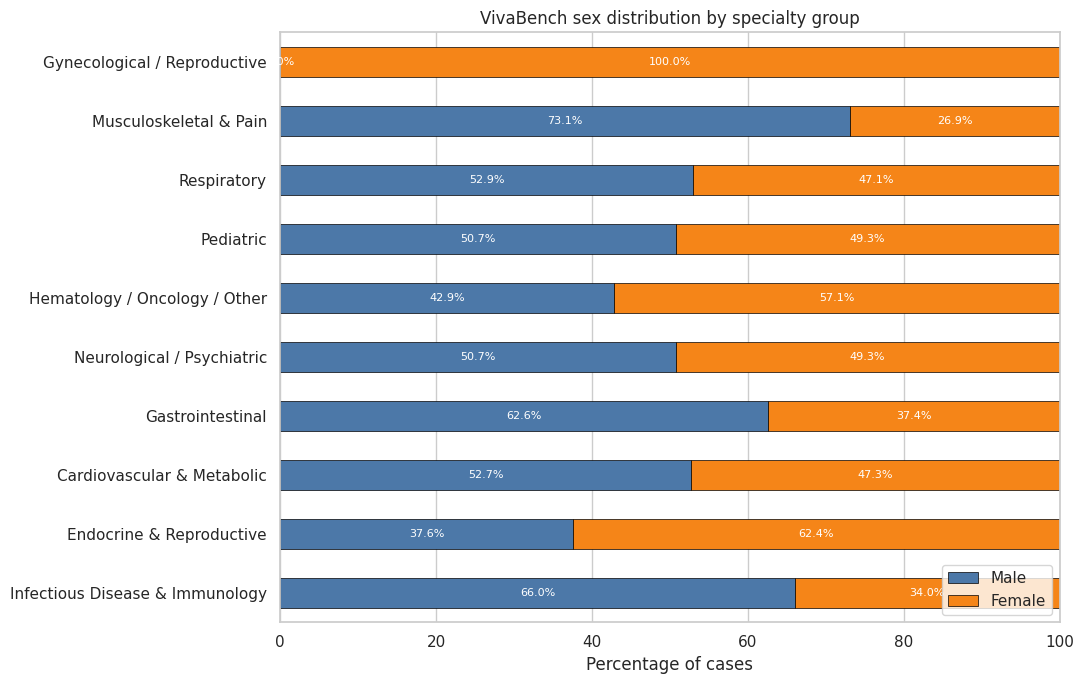

In [58]:
# VivaBench: sex by specialty group
plot_sex_by_group(
    df=df_viva_demo,
    group_col="specialty_group",
    sex_col="gender",
    title="VivaBench sex distribution by specialty group",
    output_path=cohort_dir / "vivabench_sex_by_specialty.png",
    figsize=(11, 7),
)


In [ ]:
import numpy as np
import pandas as pd

def bootstrap_accuracy_ci_from_runs(
    df_agg: pd.DataFrame,
    n_boot: int = 2000,
    ci: float = 95,
    random_state: int = 42,
):
    """
    df_agg: 一个 *_multi_run.jsonl 读进来的 dataframe
            必须包含 'runs' 列，每行对应一个 case
    返回:
        mean_accuracy, ci_low, ci_high
    """

    rng = np.random.default_rng(random_state)

    # Each case becomes one row, and each run becomes one decision (0/1) column
    decisions = []
    num_runs = max(len(runs) for runs in df_agg["runs"])

    for _, row in df_agg.iterrows():
        run_decisions = []
        runs = row["runs"]

        for i in range(num_runs):
            if i < len(runs) and isinstance(runs[i], dict):
                val = runs[i].get("effective_decision", runs[i].get("decision", None))
                run_decisions.append(np.nan if val is None else float(bool(val)))
            else:
                run_decisions.append(np.nan)

        decisions.append(run_decisions)

    decision_matrix = np.array(decisions, dtype=float)   # shape: (n_cases, n_runs)
    n_cases = decision_matrix.shape[0]

    # Raw mean accuracy: calculate accuracy for each run, then average across runs
    run_accs = np.nanmean(decision_matrix, axis=0)
    mean_accuracy = float(np.nanmean(run_accs) * 100)

    accuracy_sd = float(np.nanstd(run_accs * 100, ddof=1)) if np.sum(~np.isnan(run_accs)) > 1 else 0.0

    boot_means = []
    for _ in range(n_boot):
        sample_idx = rng.integers(0, n_cases, size=n_cases)
        sampled = decision_matrix[sample_idx, :]
        sampled_run_accs = np.nanmean(sampled, axis=0)
        boot_means.append(np.nanmean(sampled_run_accs) * 100)

    alpha = (100 - ci) / 2
    ci_low = float(np.percentile(boot_means, alpha))
    ci_high = float(np.percentile(boot_means, 100 - alpha))

    return mean_accuracy, accuracy_sd, ci_low, ci_high


In [ ]:
# AIDOC
from pathlib import Path
import numpy as np
import pandas as pd

RAW_DIR = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10")
DEMO_PATH = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts/aidoc_case_demographics.csv")

def load_aidoc_multi_run_with_demographics(raw_dir=RAW_DIR, demo_path=DEMO_PATH):
    demo = pd.read_csv(demo_path)
    demo["dataset"] = demo["dataset"].str.lower()
    demo["sex"] = demo["sex"].astype(str).str.upper()

    dfs = []
    for fp in sorted(raw_dir.glob("*_multi_run.jsonl")):
        dataset = fp.name.replace("_multi_run.jsonl", "")
        df = pd.read_json(fp, lines=True)
        df["dataset"] = dataset

        df = df.merge(
            demo[["dataset", "hadm_id", "age", "sex"]],
            on=["dataset", "hadm_id"],
            how="left",
            validate="one_to_one",
        )

        missing = df["age"].isna().sum()
        if missing:
            print(f"{dataset}: {missing} cases missing demographics")

        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    out["age_group"] = pd.cut(
        out["age"],
        bins=[-np.inf, 17, 39, 64, np.inf],
        labels=["<18", "18-39", "40-64", ">=65"],
    )

    out["sex_group"] = out["sex"].map({
        "F": "Female",
        "FEMALE": "Female",
        "M": "Male",
        "MALE": "Male",
    }).fillna("Unknown")

    return out


def summarize_accuracy_by_subgroup(df, group_col, group_label, min_n=20):
    rows = []

    for subgroup, sub in df.groupby(group_col, observed=True):
        if pd.isna(subgroup):
            continue

        n_cases = len(sub)
        mean_acc, acc_sd, ci_low, ci_high = bootstrap_accuracy_ci_from_runs(sub)

        rows.append({
            "Benchmark": "AIDOC-v2",
            "Subgroup variable": group_label,
            "Subgroup": subgroup,
            "N cases": n_cases,
            "Accuracy_mean": mean_acc,
            "Accuracy_sd_across_runs": acc_sd,
            "CI95_low": ci_low,
            "CI95_high": ci_high,
            "Interpretation": "descriptive only" if n_cases < min_n else "",
        })

    return pd.DataFrame(rows)


df_aidoc_demo_runs = load_aidoc_multi_run_with_demographics()

age_table = summarize_accuracy_by_subgroup(df_aidoc_demo_runs, "age_group", "Age")
sex_table = summarize_accuracy_by_subgroup(df_aidoc_demo_runs, "sex_group", "Sex")

demographic_accuracy_table = pd.concat([age_table, sex_table], ignore_index=True)

from pathlib import Path

OUT_DIR = RAW_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUT_DIR / "aidoc_demographic_accuracy_table.csv"
demographic_accuracy_table.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")


demographic_accuracy_table


In [ ]:
# CDM
from pathlib import Path
import numpy as np
import pandas as pd

CDM_FUZZY_DIR = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/55_clean")
CDM_DEMO_PATH = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts/cdm_case_demographics.csv")

CDM_DATASETS = [
    "appendicitis",
    "cholecystitis",
    "diverticulitis",
    "pancreatitis",
]

def load_cdm_fuzzy_runs_with_demographics(
    fuzzy_dir: Path = CDM_FUZZY_DIR,
    demo_path: Path = CDM_DEMO_PATH,
    datasets = CDM_DATASETS,
    num_runs: int = 5,
) -> pd.DataFrame:
    demo = pd.read_csv(demo_path)
    demo["dataset"] = demo["dataset"].astype(str).str.lower()
    demo["hadm_id"] = demo["hadm_id"].astype(str)
    demo["sex"] = demo["sex"].astype(str).str.upper()

    records = {}

    for run_id in range(1, num_runs + 1):
        run_dir = fuzzy_dir / f"run_{run_id}"

        for dataset in datasets:
            fp = run_dir / f"{dataset}_diagnosis_results_fuzzy.jsonl"
            if not fp.exists():
                print(f"Missing: {fp}")
                continue

            df_run = pd.read_json(fp, lines=True)
            df_run["hadm_id"] = df_run["hadm_id"].astype(str)

            for _, row in df_run.iterrows():
                hadm_id = row["hadm_id"]
                key = (dataset, hadm_id)

                if key not in records:
                    records[key] = {
                        "dataset": dataset,
                        "hadm_id": hadm_id,
                        "runs": [],
                    }

                score = row.get("gracious_diagnosis_score")
                if pd.isna(score):
                    score = row.get("diagnosis_score")

                effective_decision = bool(int(score)) if pd.notna(score) else False

                records[key]["runs"].append({
                    "run_id": int(run_id),
                    "assistant_diagnosis": row.get("assistant_diagnosis"),
                    "decision": effective_decision,
                    "effective_decision": effective_decision,
                    "diagnosis_score": row.get("diagnosis_score"),
                    "gracious_diagnosis_score": row.get("gracious_diagnosis_score"),
                })

    df_agg = pd.DataFrame(records.values())

    df_agg = df_agg.merge(
        demo[["dataset", "hadm_id", "age", "sex", "bmi"]],
        on=["dataset", "hadm_id"],
        how="left",
        validate="one_to_one",
    )

    missing_demo = df_agg["age"].isna().sum()
    print(f"Loaded {len(df_agg)} CDM cases; missing demographics: {missing_demo}")

    df_agg["age_group"] = pd.cut(
        df_agg["age"],
        bins=[-np.inf, 17, 39, 64, np.inf],
        labels=["<18", "18-39", "40-64", ">=65"],
    )

    df_agg["sex_group"] = df_agg["sex"].map({
        "F": "Female",
        "FEMALE": "Female",
        "M": "Male",
        "MALE": "Male",
    }).fillna("Unknown")

    return df_agg


def summarize_demographic_accuracy(df: pd.DataFrame, group_col: str, group_label: str, min_n: int = 20):
    rows = []

    for subgroup, sub in df.groupby(group_col, observed=True):
        if pd.isna(subgroup):
            continue

        mean_acc, acc_sd, ci_low, ci_high = bootstrap_accuracy_ci_from_runs(sub)

        rows.append({
            "Benchmark": "CDM",
            "Subgroup variable": group_label,
            "Subgroup": str(subgroup),
            "N cases": len(sub),
            "Accuracy_mean": mean_acc,
            "Accuracy_sd_across_runs": acc_sd,
            "CI95_low": ci_low,
            "CI95_high": ci_high,
            "Note": "descriptive only" if len(sub) < min_n else "",
        })

    return pd.DataFrame(rows)


df_cdm_demo_runs = load_cdm_fuzzy_runs_with_demographics()

cdm_demographic_accuracy_table = pd.concat([
    summarize_demographic_accuracy(df_cdm_demo_runs, "age_group", "Age"),
    summarize_demographic_accuracy(df_cdm_demo_runs, "sex_group", "Sex"),
], ignore_index=True)


from pathlib import Path
OUT_DIR = CDM_FUZZY_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUT_DIR / "cdm_demographic_accuracy_table.csv"
cdm_demographic_accuracy_table.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")
case_level_out_path = OUT_DIR / "cdm_case_level_runs_with_demographics.jsonl"
df_cdm_demo_runs.to_json(
    case_level_out_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

print(f"Saved to: {case_level_out_path}")



cdm_demographic_accuracy_table


In [ ]:
# Vivabench
from pathlib import Path
import numpy as np
import pandas as pd

VIVA_DIR = Path("/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/84/84.10")
VIVA_MULTI_RUN_PATH = VIVA_DIR / "vivabench_pubmed_multi_run.jsonl"
VIVA_DEMO_PATH = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts/vivabench_case_demographics.csv")

# If bootstrap_accuracy_ci_from_runs is already defined in the notebook, this block is skipped.
if "bootstrap_accuracy_ci_from_runs" not in globals():
    def bootstrap_accuracy_ci_from_runs(
        df_agg: pd.DataFrame,
        n_boot: int = 2000,
        ci: float = 95,
        random_state: int = 42,
    ):
        rng = np.random.default_rng(random_state)

        decisions = []
        num_runs = max(len(runs) for runs in df_agg["runs"])

        for _, row in df_agg.iterrows():
            run_decisions = []
            runs = row["runs"]

            for i in range(num_runs):
                if i < len(runs) and isinstance(runs[i], dict):
                    val = runs[i].get("effective_decision", runs[i].get("decision", None))
                    run_decisions.append(np.nan if val is None else float(bool(val)))
                else:
                    run_decisions.append(np.nan)

            decisions.append(run_decisions)

        decision_matrix = np.array(decisions, dtype=float)
        n_cases = decision_matrix.shape[0]

        run_accs = np.nanmean(decision_matrix, axis=0)
        mean_accuracy = float(np.nanmean(run_accs) * 100)
        accuracy_sd = float(np.nanstd(run_accs * 100, ddof=1)) if np.sum(~np.isnan(run_accs)) > 1 else 0.0

        boot_means = []
        for _ in range(n_boot):
            sample_idx = rng.integers(0, n_cases, size=n_cases)
            sampled = decision_matrix[sample_idx, :]
            sampled_run_accs = np.nanmean(sampled, axis=0)
            boot_means.append(np.nanmean(sampled_run_accs) * 100)

        alpha = (100 - ci) / 2
        ci_low = float(np.percentile(boot_means, alpha))
        ci_high = float(np.percentile(boot_means, 100 - alpha))

        return mean_accuracy, accuracy_sd, ci_low, ci_high


def load_vivabench_runs_with_demographics(
    multi_run_path: Path = VIVA_MULTI_RUN_PATH,
    demo_path: Path = VIVA_DEMO_PATH,
) -> pd.DataFrame:
    df = pd.read_json(multi_run_path, lines=True)
    df["hadm_id"] = df["hadm_id"].astype(str)

    demo = pd.read_csv(demo_path)
    demo = demo.rename(columns={
        "uid": "hadm_id",
        "gender": "sex",
    })
    demo["hadm_id"] = demo["hadm_id"].astype(str)
    demo["sex"] = demo["sex"].astype(str).str.upper()

    df = df.merge(
        demo[["hadm_id", "age", "sex", "bmi"]],
        on="hadm_id",
        how="left",
        validate="one_to_one",
    )

    missing_demo = df["age"].isna().sum()
    print(f"Loaded {len(df)} VivaBench cases; missing demographics: {missing_demo}")

    df["age_group"] = pd.cut(
        df["age"],
        bins=[-np.inf, 17, 39, 64, np.inf],
        labels=["<18", "18-39", "40-64", ">=65"],
    )

    df["sex_group"] = df["sex"].map({
        "F": "Female",
        "FEMALE": "Female",
        "WOMAN": "Female",
        "M": "Male",
        "MALE": "Male",
        "MAN": "Male",
    }).fillna("Unknown")

    return df


def summarize_vivabench_demographic_accuracy(
    df: pd.DataFrame,
    group_col: str,
    group_label: str,
    min_n: int = 20,
) -> pd.DataFrame:
    rows = []

    for subgroup, sub in df.groupby(group_col, observed=True):
        if pd.isna(subgroup):
            continue

        mean_acc, acc_sd, ci_low, ci_high = bootstrap_accuracy_ci_from_runs(sub)

        rows.append({
            "Benchmark": "VivaBench",
            "Subgroup variable": group_label,
            "Subgroup": str(subgroup),
            "N cases": len(sub),
            "Accuracy_mean": mean_acc,
            "Accuracy_sd_across_runs": acc_sd,
            "CI95_low": ci_low,
            "CI95_high": ci_high,
            "Note": "descriptive only" if len(sub) < min_n else "",
        })

    return pd.DataFrame(rows)


df_viva_demo_runs = load_vivabench_runs_with_demographics()

vivabench_demographic_accuracy_table = pd.concat([
    summarize_vivabench_demographic_accuracy(df_viva_demo_runs, "age_group", "Age"),
    summarize_vivabench_demographic_accuracy(df_viva_demo_runs, "sex_group", "Sex"),
], ignore_index=True)

# Save outputs
table_out_path = VIVA_DIR / "vivabench_demographic_accuracy_table.csv"
case_level_out_path = VIVA_DIR / "vivabench_case_level_runs_with_demographics.jsonl"

vivabench_demographic_accuracy_table.to_csv(table_out_path, index=False)

df_viva_demo_runs.to_json(
    case_level_out_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

print(f"Saved table to: {table_out_path}")
print(f"Saved case-level data to: {case_level_out_path}")

vivabench_demographic_accuracy_table


/tmp/ipykernel_2759208/2375920094.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.4)


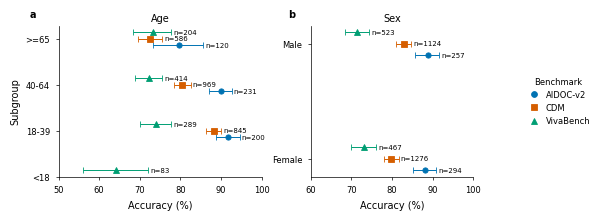

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

paths = [
    Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10/aidoc_demographic_accuracy_table.csv"),
    Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/55_clean/cdm_demographic_accuracy_table.csv"),
    Path("/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/84/84.10/vivabench_demographic_accuracy_table.csv"),
]

df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)

benchmark_order = ["AIDOC-v2", "CDM", "VivaBench"]
age_order = ["<18", "18-39", "40-64", ">=65"]
sex_order = ["Female", "Male"]

df["Benchmark"] = pd.Categorical(df["Benchmark"], benchmark_order, ordered=True)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 6,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.title_fontsize": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
})

benchmark_style = {
    "AIDOC-v2": {"color": "#0072B2", "marker": "o"},
    "CDM": {"color": "#D55E00", "marker": "s"},
    "VivaBench": {"color": "#009E73", "marker": "^"},
}

fig_width = 170 / 25.4
fig_height = 50 / 25.4

fig, axes = plt.subplots(
    1,
    3,
    figsize=(fig_width, fig_height),
    gridspec_kw={
        "width_ratios": [5, 4, 1.35],
        "wspace": 0.35,
    },
)

plot_axes = axes[:2]
legend_ax = axes[2]
legend_ax.axis("off")

benchmark_offsets_by_variable = {
    "Age": {"AIDOC-v2": -0.22, "CDM": 0.00, "VivaBench": 0.22},
    "Sex": {"AIDOC-v2": -0.05, "CDM": 0.00, "VivaBench": 0.05},
}

subgroup_gap_by_variable = {
    "Age": 1.55,
    "Sex": 0.50,
}

for ax, variable, subgroup_order, panel_label in [
    (plot_axes[0], "Age", age_order, "a"),
    (plot_axes[1], "Sex", sex_order, "b"),
]:
    subgroup_gap = subgroup_gap_by_variable[variable]
    benchmark_offsets = benchmark_offsets_by_variable[variable]

    sub = df[df["Subgroup variable"] == variable].copy()
    sub["Subgroup"] = pd.Categorical(sub["Subgroup"], subgroup_order, ordered=True)
    sub = sub.sort_values(["Subgroup", "Benchmark"])

    y_positions = []
    y_labels = []

    for idx, subgroup in enumerate(subgroup_order):
        base_y = idx * subgroup_gap
        sg = sub[sub["Subgroup"] == subgroup]
        if sg.empty:
            continue

        for benchmark in benchmark_order:
            row = sg[sg["Benchmark"] == benchmark]
            if row.empty:
                continue

            row = row.iloc[0]
            y = base_y + benchmark_offsets[benchmark]
            style = benchmark_style[benchmark]

            ax.errorbar(
                row["Accuracy_mean"],
                y,
                xerr=[
                    [row["Accuracy_mean"] - row["CI95_low"]],
                    [row["CI95_high"] - row["Accuracy_mean"]],
                ],
                fmt=style["marker"],
                color=style["color"],
                ecolor=style["color"],
                markersize=3.8,
                markeredgewidth=0.6,
                elinewidth=0.7,
                capsize=2.0,
                capthick=0.7,
                alpha=1.0,
            )

            ax.text(
                row["CI95_high"] + 0.5,
                y,
                f"n={int(row['N cases'])}",
                va="center",
                fontsize=5,
                color="black",
            )

        y_positions.append(base_y)
        y_labels.append(subgroup)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels)
    ax.set_title(variable, pad=3)
    ax.set_xlabel("Accuracy (%)")
    ax.grid(False)

    if variable == "Sex":
        ax.set_xlim(60, 100)
        ax.set_xticks([60, 70, 80, 90, 100])
    else:
        ax.set_xlim(50, 100)
        ax.set_xticks([50, 60, 70, 80, 90, 100])

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=2.5,
        width=0.5,
        color="black",
        bottom=True,
        left=True,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        -0.14,
        1.04,
        panel_label,
        transform=ax.transAxes,
        fontsize=7,
        fontweight="bold",
        va="bottom",
        ha="left",
    )

plot_axes[0].set_ylabel("Subgroup")

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=benchmark_style[b]["marker"],
        color=benchmark_style[b]["color"],
        label=b,
        linestyle="None",
        markersize=4.2,
        markeredgewidth=0.6,
    )
    for b in benchmark_order
]

legend_ax.legend(
    handles=legend_handles,
    title="Benchmark",
    loc="center left",
    frameon=False,
    handletextpad=0.4,
    borderaxespad=0.0,
)

plt.tight_layout(pad=0.4)

out_dir = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts")
out_dir.mkdir(parents=True, exist_ok=True)

base = out_dir / "demographic_accuracy_forest_plot"

plt.savefig(base.with_suffix(".svg"), bbox_inches="tight")
plt.savefig(base.with_suffix(".pdf"), bbox_inches="tight")
plt.savefig(base.with_suffix(".png"), dpi=600, bbox_inches="tight")

plt.show()


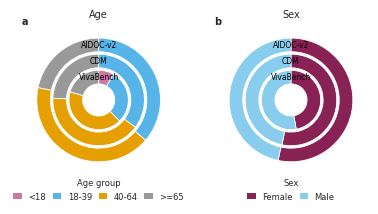

Age counts


age_group,<18,18-39,40-64,>=65
Benchmark,,,,
AIDOC-v2,0,200,231,120
CDM,0,845,969,586
VivaBench,83,289,414,204


Sex counts


sex_group,Female,Male
Benchmark,,
AIDOC-v2,294,257
CDM,1276,1124
VivaBench,467,523


In [45]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

AIDOC_DEMO_PATH = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts/aidoc_case_demographics.csv")
CDM_DEMO_PATH = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts/cdm_case_demographics.csv")
VIVA_DEMO_PATH = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts/vivabench_case_demographics.csv")

benchmark_order = ["AIDOC-v2", "CDM", "VivaBench"]
age_order = ["<18", "18-39", "40-64", ">=65"]
sex_order = ["Female", "Male"]

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 6,
    "axes.titlesize": 7,
    "legend.fontsize": 6,
    "legend.title_fontsize": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

def load_demographics():
    aidoc = pd.read_csv(AIDOC_DEMO_PATH)
    aidoc = aidoc.rename(columns={"sex": "sex"})
    aidoc["Benchmark"] = "AIDOC-v2"

    cdm = pd.read_csv(CDM_DEMO_PATH)
    cdm = cdm.rename(columns={"sex": "sex"})
    cdm["Benchmark"] = "CDM"

    viva = pd.read_csv(VIVA_DEMO_PATH)
    viva = viva.rename(columns={
        "gender": "sex",
        "uid": "case_id",
    })
    viva["Benchmark"] = "VivaBench"

    df = pd.concat([
        aidoc[["Benchmark", "age", "sex"]],
        cdm[["Benchmark", "age", "sex"]],
        viva[["Benchmark", "age", "sex"]],
    ], ignore_index=True)

    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df["sex"] = df["sex"].astype(str).str.upper()

    df["sex_group"] = df["sex"].map({
        "F": "Female",
        "FEMALE": "Female",
        "WOMAN": "Female",
        "M": "Male",
        "MALE": "Male",
        "MAN": "Male",
    })

    df["age_group"] = pd.cut(
        df["age"],
        bins=[-np.inf, 17, 39, 64, np.inf],
        labels=age_order,
    )

    return df


def count_table(df, group_col, subgroup_order):
    table = (
        df.dropna(subset=[group_col])
        .pivot_table(
            index="Benchmark",
            columns=group_col,
            values="age",
            aggfunc="count",
            fill_value=0,
            observed=True,
        )
        .reindex(index=benchmark_order, columns=subgroup_order, fill_value=0)
    )
    return table


age_colors = {
    "<18": "#CC79A7",     # reddish purple
    "18-39": "#56B4E9",  # sky blue
    "40-64": "#E69F00",  # orange
    ">=65": "#999999",   # grey
}

sex_colors = {
    "Female": "#882255",  # wine
    "Male": "#88CCEE",    # light blue
}


def draw_nested_donut(ax, table, subgroup_order, colors, title, panel_label):
    ring_width = 0.22
    radii = [1.00, 0.74, 0.48]

    for radius, benchmark in zip(radii, benchmark_order):
        values = table.loc[benchmark, subgroup_order].astype(float).values

        ax.pie(
            values,
            radius=radius,
            colors=[colors[g] for g in subgroup_order],
            startangle=90,
            counterclock=False,
            wedgeprops={
                "width": ring_width,
                "edgecolor": "white",
                "linewidth": 0.6,
            },
        )

        ax.text(
            0,
            radius - ring_width / 2,
            benchmark,
            ha="center",
            va="center",
            fontsize=5.5,
            color="black",
        )

    ax.set(aspect="equal")
    ax.set_title(title, pad=4)

    ax.text(
        -1.25,
        1.20,
        panel_label,
        fontsize=7,
        fontweight="bold",
        ha="left",
        va="bottom",
    )


df_demo = load_demographics()

age_table = count_table(df_demo, "age_group", age_order)
sex_table = count_table(df_demo, "sex_group", sex_order)

fig_width = 100 / 25.4
fig_height = 50 / 25.4

fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height))

draw_nested_donut(
    axes[0],
    age_table,
    age_order,
    age_colors,
    "Age",
    "a",
)

draw_nested_donut(
    axes[1],
    sex_table,
    sex_order,
    sex_colors,
    "Sex",
    "b",
)

axes[0].legend(
    handles=[Patch(facecolor=age_colors[g], edgecolor="none", label=g) for g in age_order],
    title="Age group",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=4,
    frameon=False,
    handlelength=1.0,
    columnspacing=0.8,
)

axes[1].legend(
    handles=[Patch(facecolor=sex_colors[g], edgecolor="none", label=g) for g in sex_order],
    title="Sex",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    frameon=False,
    handlelength=1.0,
    columnspacing=0.8,
)

plt.tight_layout()

out_dir = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts")
out_dir.mkdir(parents=True, exist_ok=True)

base = out_dir / "demographic_composition_nested_donut_from_case_demographics"

plt.savefig(base.with_suffix(".svg"), bbox_inches="tight")
plt.savefig(base.with_suffix(".pdf"), bbox_inches="tight")
plt.savefig(base.with_suffix(".png"), dpi=600, bbox_inches="tight")

plt.show()

print("Age counts")
display(age_table)

print("Sex counts")
display(sex_table)


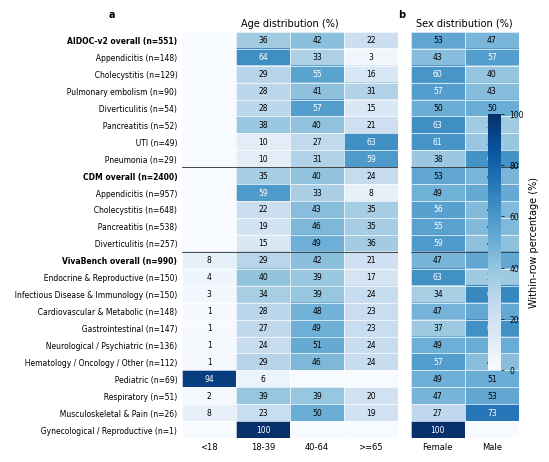

Saved figure to: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts/ v.svg
Saved source tables to: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ======================
# Paths
# ======================
paths = {
    "AIDOC-v2": Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts/aidoc_case_demographics.csv"),
    "CDM": Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts/cdm_case_demographics.csv"),
    "VivaBench": Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts/vivabench_case_demographics.csv"),
}

out_dir = Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts")
out_dir.mkdir(parents=True, exist_ok=True)

benchmark_order = ["AIDOC-v2", "CDM", "VivaBench"]
age_order = ["<18", "18-39", "40-64", ">=65"]
sex_order = ["Female", "Male"]

disease_label_map = {
    "appendicitis": "Appendicitis",
    "cholecystitis": "Cholecystitis",
    "diverticulitis": "Diverticulitis",
    "pancreatitis": "Pancreatitis",
    "pulmonary_embolism": "Pulmonary embolism",
    "pneumonia": "Pneumonia",
    "uti": "UTI",
}

# ======================
# helpers
# ======================
def set_style():
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 5.5,
        "legend.fontsize": 6,
        "legend.title_fontsize": 6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 0.5,
    })

def mm_to_inch(mm):
    return mm / 25.4

def save_figure(fig, out_base):
    out_base = Path(out_base)
    fig.savefig(out_base.with_suffix(".svg"), bbox_inches="tight")
    fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(out_base.with_suffix(".png"), dpi=600, bbox_inches="tight")

def add_panel_label(ax, label, x=-0.08, y=1.03):
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=7,
        fontweight="bold",
        va="bottom",
        ha="left",
    )

# ======================
# Load and normalize
# ======================
def normalize_sex(x):
    if pd.isna(x):
        return "Unknown"

    x = str(x).strip().upper()

    if x in {"F", "FEMALE", "WOMAN", "W"}:
        return "Female"
    if x in {"M", "MALE", "MAN"}:
        return "Male"

    return "Unknown"

def format_disease_label(x):
    if pd.isna(x):
        return "Unknown"

    x = str(x).strip()
    return disease_label_map.get(x, x.replace("_", " ").title())

frames = []

for benchmark, path in paths.items():
    raw = pd.read_csv(path)

    if benchmark == "VivaBench":
        tmp = pd.DataFrame({
            "Benchmark": benchmark,
            "case_id": raw["uid"].astype(str),
            "Group type": "Specialty group",
            "Group": raw["specialty_group"].fillna("Unknown").astype(str),
            "Age": pd.to_numeric(raw["age"], errors="coerce"),
            "Sex": raw["gender"].map(normalize_sex),
        })
    else:
        tmp = pd.DataFrame({
            "Benchmark": benchmark,
            "case_id": raw["hadm_id"].astype(str),
            "Group type": "Disease",
            "Group": raw["dataset"].map(format_disease_label),
            "Age": pd.to_numeric(raw["age"], errors="coerce"),
            "Sex": raw["sex"].map(normalize_sex),
        })

    frames.append(tmp)

df_demo = pd.concat(frames, ignore_index=True)

df_demo["Age group"] = pd.cut(
    df_demo["Age"],
    bins=[-np.inf, 17, 39, 64, np.inf],
    labels=age_order,
)

df_demo["Age group"] = df_demo["Age group"].astype(object)
df_demo.loc[df_demo["Age group"].isna(), "Age group"] = "Unknown"

age_order_plot = age_order.copy()
if (df_demo["Age group"] == "Unknown").any():
    age_order_plot.append("Unknown")

sex_order_plot = sex_order.copy()
if (df_demo["Sex"] == "Unknown").any():
    sex_order_plot.append("Unknown")

# ======================
# Build row order
# ======================
group_orders = {}

for benchmark in benchmark_order:
    group_orders[benchmark] = (
        df_demo.loc[df_demo["Benchmark"] == benchmark, "Group"]
        .value_counts()
        .index
        .tolist()
    )

dist_overall = df_demo.copy()
dist_overall["Row group"] = "Overall"

dist_group = df_demo.copy()
dist_group["Row group"] = dist_group["Group"]

df_dist = pd.concat([dist_overall, dist_group], ignore_index=True)

row_keys = []
for benchmark in benchmark_order:
    row_keys.append((benchmark, "Overall"))
    for group in group_orders[benchmark]:
        row_keys.append((benchmark, group))

row_index = pd.MultiIndex.from_tuples(row_keys, names=["Benchmark", "Row group"])

row_n = (
    df_dist
    .groupby(["Benchmark", "Row group"])
    .size()
    .reindex(row_index, fill_value=0)
)

row_labels = []

for benchmark, row_group in row_keys:
    n = int(row_n.loc[(benchmark, row_group)])

    if row_group == "Overall":
        row_labels.append(f"{benchmark} overall (n={n})")
    else:
        row_labels.append(f"  {row_group} (n={n})")

# ======================
# Distribution tables
# ======================
def make_distribution_tables(variable, columns):
    counts = (
        df_dist
        .groupby(["Benchmark", "Row group", variable])
        .size()
        .unstack(variable, fill_value=0)
    )

    counts = counts.reindex(index=row_index, fill_value=0)
    counts = counts.reindex(columns=columns, fill_value=0)

    pct = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0) * 100
    pct = pct.fillna(0)

    return counts, pct

age_counts, age_pct = make_distribution_tables("Age group", age_order_plot)
sex_counts, sex_pct = make_distribution_tables("Sex", sex_order_plot)

# Save source tables
age_counts.reset_index().to_csv(
    out_dir / "cohort_age_distribution_counts.csv",
    index=False,
)

age_pct.round(2).reset_index().to_csv(
    out_dir / "cohort_age_distribution_percent.csv",
    index=False,
)

sex_counts.reset_index().to_csv(
    out_dir / "cohort_sex_distribution_counts.csv",
    index=False,
)

sex_pct.round(2).reset_index().to_csv(
    out_dir / "cohort_sex_distribution_percent.csv",
    index=False,
)

# ======================
# Plot helper
# ======================
def benchmark_block_separators():
    separators = []
    pos = 0

    for benchmark in benchmark_order:
        block_size = len(group_orders[benchmark]) + 1
        pos += block_size
        separators.append(pos - 0.5)

    return separators[:-1]

def draw_pct_heatmap(ax, pct_df, count_df, columns, title, show_ylabels=True):
    values = pct_df.to_numpy(dtype=float)
    counts = count_df.to_numpy(dtype=int)

    im = ax.imshow(
        values,
        cmap="Blues",
        vmin=0,
        vmax=100,
        aspect="auto",
    )

    ax.set_xticks(np.arange(len(columns)))
    ax.set_xticklabels(columns)

    ax.set_yticks(np.arange(len(row_labels)))

    if show_ylabels:
        ax.set_yticklabels(row_labels)

        for tick_label, (_, row_group) in zip(ax.get_yticklabels(), row_keys):
            if row_group == "Overall":
                tick_label.set_fontweight("bold")
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", left=False)


    ax.set_title(title, pad=4)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if counts[i, j] == 0:
                continue

            value = values[i, j]
            text_color = "white" if value >= 55 else "black"

            ax.text(
                j,
                i,
                f"{value:.0f}",
                ha="center",
                va="center",
                fontsize=5.5,
                color=text_color,
            )

    ax.set_xticks(np.arange(-0.5, len(columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    for sep in benchmark_block_separators():
        ax.axhline(sep, color="black", linewidth=0.5)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="major", length=0)

    return im

# ======================
# Plot
# ======================
set_style()

fig = plt.figure(figsize=(mm_to_inch(150), mm_to_inch(120)))

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[4.0, 2.0],
    wspace=0.08,
)

ax_age = fig.add_subplot(gs[0, 0])
ax_sex = fig.add_subplot(gs[0, 1])

im_age = draw_pct_heatmap(
    ax_age,
    age_pct,
    age_counts,
    age_order_plot,
    "Age distribution (%)",
    show_ylabels=True,
)

im_sex = draw_pct_heatmap(
    ax_sex,
    sex_pct,
    sex_counts,
    sex_order_plot,
    "Sex distribution (%)",
    show_ylabels=False,
)

add_panel_label(ax_age, "a", x=-0.34, y=1.03)
add_panel_label(ax_sex, "b", x=-0.12, y=1.03)

cbar = fig.colorbar(
    im_age,
    ax=[ax_age, ax_sex],
    fraction=0.028,
    pad=0.02,
)

cbar.set_label("Within-row percentage (%)")
cbar.ax.tick_params(length=2.5, width=0.5)
cbar.outline.set_visible(False)
for spine in cbar.ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(
    left=0.36,
    right=0.93,
    top=0.94,
    bottom=0.08,
)

base = out_dir / "benchmark_cohort_age_sex_distribution_heatmap"
save_figure(fig, base)

plt.show()

print(f"Saved figure to: {base.with_suffix('.svg')}")
print(f"Saved source tables to: {out_dir}")
